In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from  sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [10]:
df = pd.read_csv('/home/bitbug/Documents/Shell/predict_energy_consumption.csv')
df.head()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
0,24.363503,31.107976,5.234114,705.432695,307.398145
1,38.767858,52.514057,4.939576,817.013257,412.444548
2,33.299849,72.376750,18.125092,325.421109,392.072418
3,29.966462,63.933493,4.990924,662.386690,119.254957
4,18.900466,68.393669,5.438995,614.571385,117.162261


In [11]:
X = df[['temperature', 'humidity', 'wind_speed','solar_irradiance']]
y = df['energy_consumption'].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])


In [16]:
model.compile(optimizer='adam', loss='mse',metrics=['mae'])

In [17]:
history = model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2,verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 89989.2266 - mae: 271.0115 - val_loss: 83240.7109 - val_mae: 258.1394
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 89331.3516 - mae: 269.8096 - val_loss: 82479.0234 - val_mae: 256.6588
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 88335.3125 - mae: 267.9380 - val_loss: 81268.8203 - val_mae: 254.2887
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 86760.0469 - mae: 264.9977 - val_loss: 79432.5078 - val_mae: 250.6487
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 84435.9531 - mae: 260.5572 - val_loss: 76743.7969 - val_mae: 245.2149
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 81094.6094 - mae: 254.0720 - val_loss: 73089.8516 - val_mae: 237.6274
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 76668.5078 - mae: 245.1880 - val_loss: 68358.6953 - val_mae: 227.3957
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 71134.8359 - mae: 233.4308 - val_loss:

In [18]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=1)
print(f'Test MAE: {test_mae:.2f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 18126.1777 - mae: 116.1410 
Test MAE: 116.14


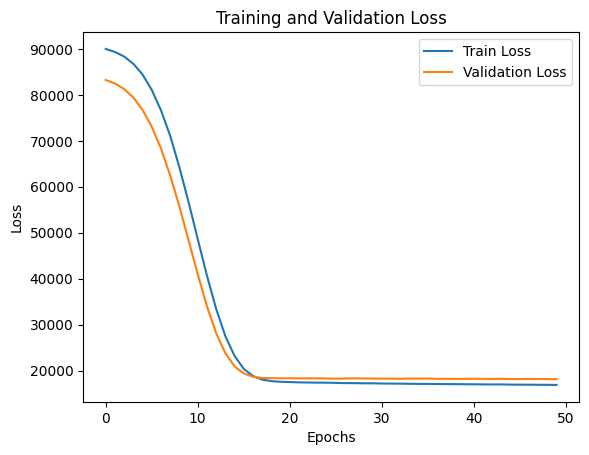

In [20]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


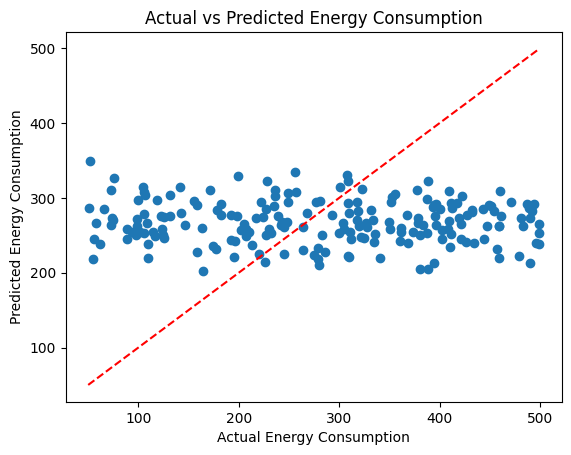

In [21]:
predictions = model.predict(X_test_scaled)
plt.scatter(y_test, predictions)
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Actual vs Predicted Energy Consumption')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show() 
